# Real data: human calibration --- Figures 4, 10, 11, 12

Study 3, judge panels across budget regimes (appendix G.4.2), plus the main-text calibration figure.
Three sweeps drawn on the same 3 x 3 grid (datasets x judge panels `small6` / `large6` / `all`):

| Figure | Sweep | Fixed |
|---|---|---|
| `fig_small_panel` (Fig. 10) | human budget $n_H$ | as-collected LLM data |
| `fig_small_panel_llmbudget` (Fig. 11) | LLM budget $n_L$ | $n_H = 300 / 80 / 60$ |
| `fig_intermediate_budget` (Fig. 12) | human budget $n_H$ | $n_L = 2{,}000 / 160 / 100$ |

Metric: excess held-out log loss, the version used in the manuscript.
Kendall's $\tau$ is recorded per cell as well and is the metric of Figure 4; `show(name, metrics=METRIC)` draws both.
Bands are $\pm1.96$ Monte Carlo s.e. over 50 splits.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))

from experiments.real_data.panel_budget import (
    FIGURES, INTERMEDIATE_NL, METRIC, RCPARAMS, ROOT,
    figure_kwargs, figure_name, figure_rows, intermediate_data, panel_budget_data, panel_grid,
)

FIG_DIR = REPO / "figures"
summary = panel_budget_data()                    # robustness rows; asserts all 50 seeds per cell
intermediate, seeds = intermediate_data(ROOT / "results" / "intermediate_budget")


def show(name, metrics=("excess",)):
    """Draw one figure from the module's own spec and save it as the CLI does.

    Only the excess-log-loss versions are in the manuscript; pass `metrics=METRIC` for the
    Kendall-tau companions as well."""
    rows = figure_rows(name, summary, intermediate)
    for metric in metrics:
        with plt.rc_context(RCPARAMS):
            fig = panel_grid(rows, **figure_kwargs(name, metric, rows))
            fig.savefig(FIG_DIR / f"{figure_name(name, metric)}.pdf", bbox_inches="tight", dpi=300)
            plt.show()


print(f"{len(summary)} budget/llm_budget rows, {len(intermediate)} intermediate rows ({seeds} seeds)")

306 budget/llm_budget rows, 171 intermediate rows (50 seeds)


## Figure 4 (main text): human-label efficiency on Chatbot Arena

The Arena `all` cells of sweeps 1 and 3 on one shared $\tau$ axis: (a) the collected LLM judgments, (b) the intermediate budget $n_L=2{,}000$.
Human-only is drawn only at the budgets where its unrestricted MLE exists in all 50 splits; the dashed line marks that threshold.


human budgets with a finite MLE in every split: [800, 1600, 3802]


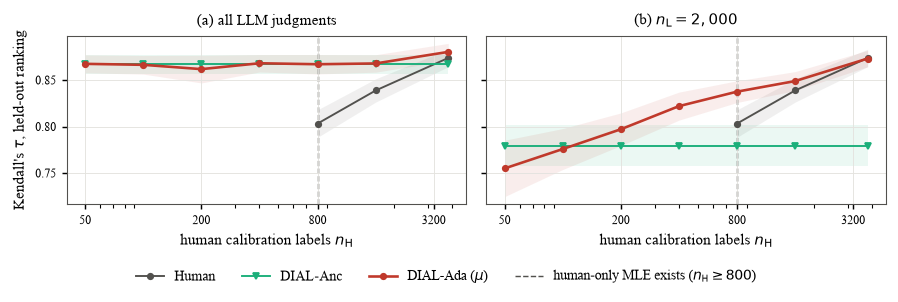

In [2]:
from experiments.real_data.panel_budget import calibration_figure, human_exists_budgets

print("human budgets with a finite MLE in every split:", sorted(human_exists_budgets()))
with plt.rc_context(RCPARAMS):
    fig = calibration_figure(summary, intermediate)
    fig.savefig(FIG_DIR / "fig_real_calibration.pdf", bbox_inches="tight", dpi=300)
    plt.show()


## Figure 10 (appendix): human budget at the collected LLM data

Where the small panel does and does not close the gap to `large6`, `all`, and human-only.


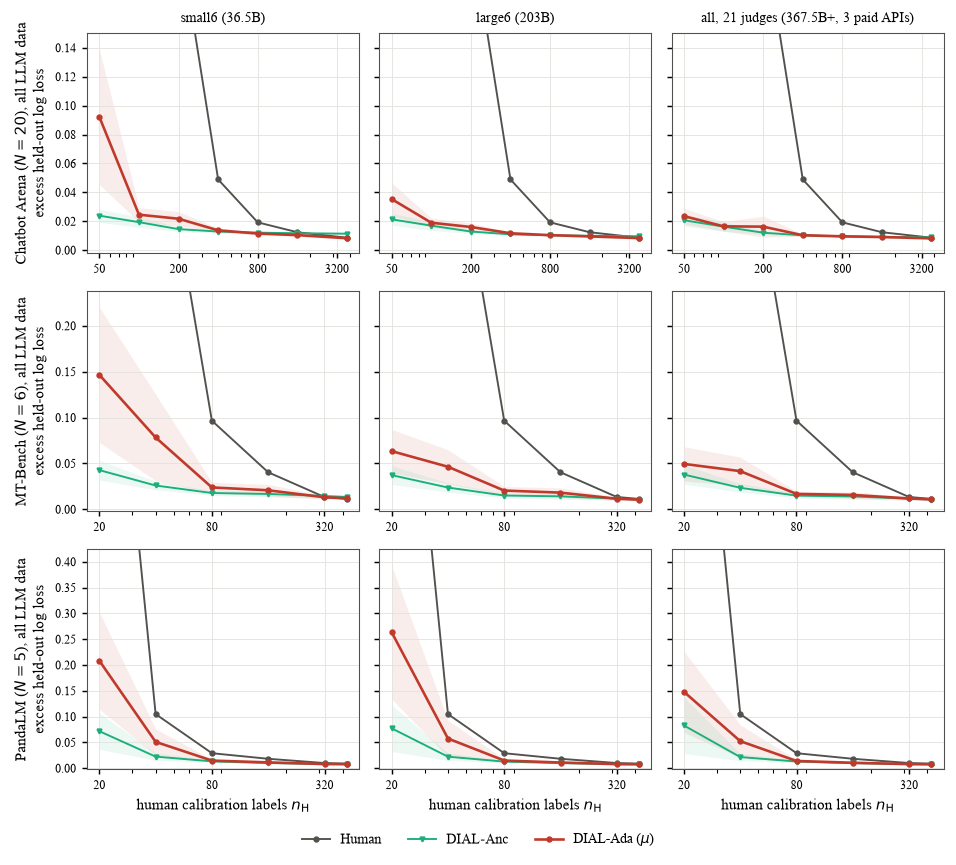

In [3]:
show("fig_small_panel")

## Figure 11 (appendix): LLM budget at a fixed human budget

The reverse constraint: an imprecise LLM-only direction limits DIAL-Anc, while DIAL-Ada ($\mu$) can re-estimate $\mu$ from the human comparisons.


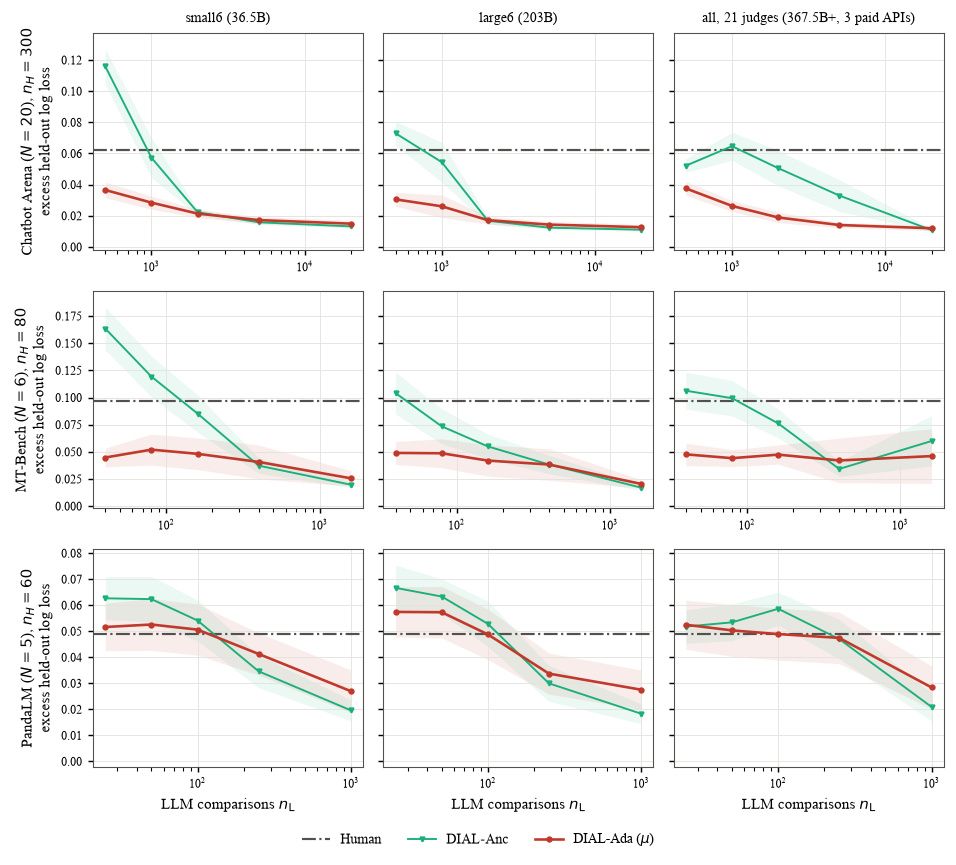

In [4]:
show("fig_small_panel_llmbudget")

## Figure 12 (appendix): human budget at a fixed intermediate LLM budget

The middle LLM level of sweep 2, where keeping the LLM-only consensus direction (DIAL-Anc) and letting human comparisons update it (DIAL-Ada) cross over.


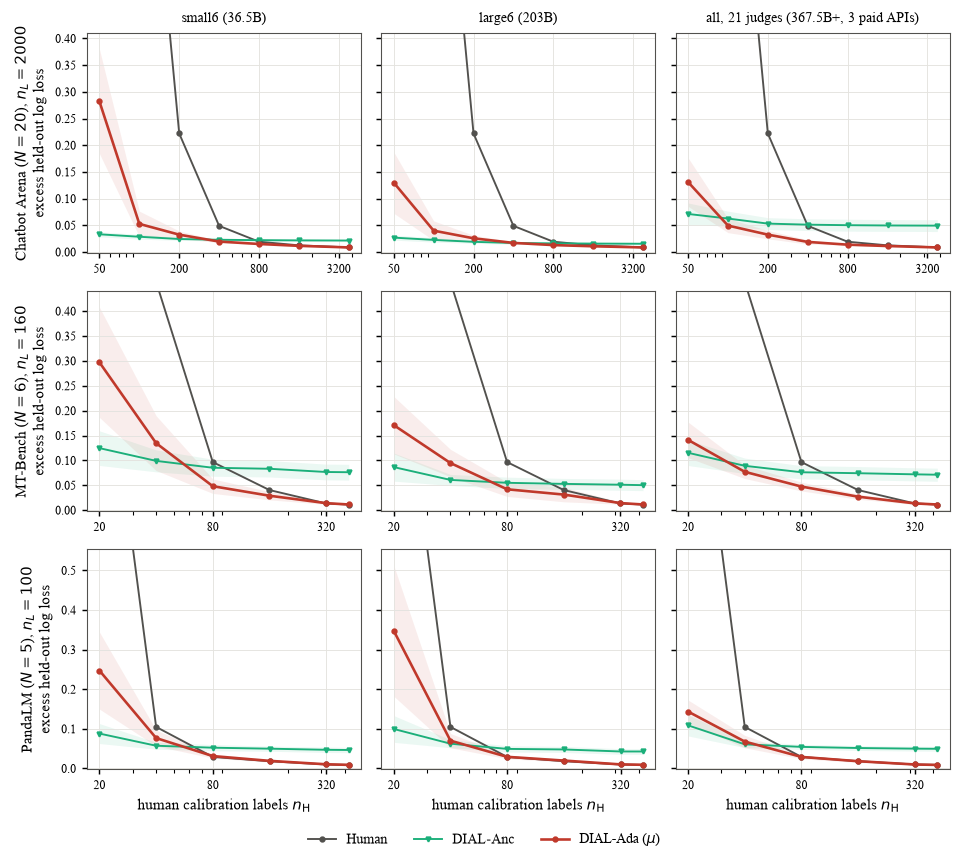

In [5]:
show("fig_intermediate_budget")

## Full-pool comparison in both metrics

DIAL-$\mu$ against Cons-Cal at the largest tested human budget: the log-loss ratio, the
$\tau$ gain, and whether each beats Cons-Cal by more than two paired Monte Carlo standard
errors.

In [6]:
rows = []
for (ds, panel), g in intermediate.groupby(["dataset", "panel"]):
    top = g[g.n_H == g.n_H.max()].set_index("method")
    rows.append(dict(dataset=ds, panel=panel, n_H=round(g.n_H.max()),
                     loss_cons=top.loc["consensus_cal", "excess"], loss_dial=top.loc["dial_mu", "excess"],
                     loss_ratio=top.loc["consensus_cal", "excess"] / top.loc["dial_mu", "excess"],
                     tau_cons=top.loc["consensus_cal", "tau"], tau_dial=top.loc["dial_mu", "tau"],
                     tau_gain=top.loc["dial_mu", "tau"] - top.loc["consensus_cal", "tau"],
                     loss_signif=bool(top.loc["dial_mu", "delta_vs_cons"]
                                      < -2 * top.loc["dial_mu", "paired_mcse"])))
pd.DataFrame(rows).round(4)

,dataset,panel,n_H,loss_cons,loss_dial,loss_ratio,tau_cons,tau_dial,tau_gain,loss_signif
0,arena_33k,all,3802,0.0493,0.0085,5.7976,0.7796,0.8731,0.0935,True
1,arena_33k,large6,3802,0.0154,0.0085,1.8125,0.8234,0.8726,0.0493,True
2,arena_33k,small6,3802,0.0214,0.0085,2.5153,0.7808,0.8747,0.0939,True
3,mt_bench,all,422,0.0712,0.0113,6.2858,0.6773,0.8747,0.1973,True
4,mt_bench,large6,422,0.0502,0.0114,4.4088,0.7867,0.8987,0.1120,True
5,mt_bench,small6,422,0.0762,0.0114,6.7032,0.7200,0.8880,0.1680,True
6,pandalm,all,421,0.0496,0.0089,5.5813,0.3840,0.8280,0.4440,True
7,pandalm,large6,421,0.0428,0.0092,4.6476,0.4520,0.8240,0.3720,True
8,pandalm,small6,421,0.0466,0.0090,5.1740,0.4120,0.8160,0.4040,True


## Descriptive crossover locations

The first tested human budget at which DIAL-$\mu$ beats Cons-Cal by more than two paired Monte
Carlo standard errors, and keeps doing so at every higher budget (appendix Table 3). A post hoc
summary of these curves, not a calibrated test or a switching rule for new data.

In [7]:
def crossover(frame):
    out = []
    for (ds, panel), g in frame.groupby(["dataset", "panel"]):
        g = g[g.method == "dial_mu"].sort_values("n_H").set_index("n_H")
        better = g.delta_vs_cons < -2 * g.paired_mcse
        first = next((n for n in better.index if better.loc[n:].all()), None)
        out.append(dict(dataset=ds, panel=panel, n_L=INTERMEDIATE_NL[ds], crossover_n_H=first))
    return pd.DataFrame(out)

crossover(intermediate).pivot(index="dataset", columns="panel", values="crossover_n_H")

panel,all,large6,small6
dataset,,,
arena_33k,200.0,800.0,400.0
mt_bench,80.0,160.0,80.0
pandalm,80.0,80.0,80.0
